# List of Environmental conditions to consider

For the SFT projects, consider the following environmental parameters for your analysis.

- Wind-sea (operation and ultimate state)
- Swell-sea (operation and ultimate state)
- Wave direction: Present the wave-direction rose diagram for wind-sea and swell-sea. <br> Consider only the dominant directions for your analysis. 
- Current speed and direction (operation and ultimate state)
- Tide (esp. if using pontoons) (operation and ultimate range)
- Seismic activity (if applicable)

# Extracting data from online dataset

We present the procedure for extracting the Hs and Tz for a location from online dataset.

## 1. Download data from online dataset

The following steps can be taken to extract environmental data at the location: 

1. Log in with user account on the site: <br>
https://cds.climate.copernicus.eu/ <br>
Use e-mail: makeYourEmailAccount<br>
Password: Password<br>
<img width="80%" src="./img/nb01_fig001.png" />

1. Select **Datasets** and look for **ERA5 hourly data on single levels from 1940 to present**<br>
<img width="80%" src="./img/nb01_fig001f.png" />

1. Select **Download** and choose **Reanalysis** <br>
<img width="80%" src="./img/nb01_fig002.png" />

1. Here you may pick one or two variables of interest. <br>
It is noted that more detailed ocean waves data can be found under a separate tab. <br>
<img width="80%" src="./img/nb01_fig002b_2.png" /><br>
We are interested in 

- **Significant height of wind waves**.
- **Significant height of total swell**
- **Peak wave period**
- **Significant height of combined wind waves and swell waves**


1. Choose one or several years. <br> 
For the statistical review it is important to have a number of years but the data which can be extracted is limited. <br> 
The choice here is to extract the years **2018**, **2019**, **2020** and **2021**. Next to this all year is chosen **January** etc. as well as all days.  <br>
<img width="80%" src="./img/nb01_fig003.png" /> 

1. For the time three hour values are chosen (to reduce the amount of data).  <br>
<img width="80%" src="./img/nb01_fig004.png" /> 

1. For Geographical area choose **Sub-region**. The longitude & latitude limits are given at the western and eastern side as well as Northern and Southern side. Data is extracted in the area between the values. <br>
<img width="80%" src="./img/nb01_fig005.png" /> 

1. On the format choose **NetCFD** <br>
<img width="80%" src="./img/nb01_fig006.png" /> 

1. If all has been filled in correctly data can be extracted. **Submit Form** <br>
<img width="80%" src="./img/nb01_fig007.png" /> 

1. The request is now shown in a new page and by expanding the product details are shown. This request took around 8 min to deliver. <br>
<img width="80%" src="./img/nb01_fig008.png" /> 

1. The data can be downloaded. Once this is done the Python script can be used to extract the data.  <br>
<img width="80%" src="./img/nb01_fig009.png" /> 


## 2. Extract data from dataset

This is achieved using **netCDF4** package

In [2]:
from netCDF4 import Dataset
nc = Dataset('data/Hs_Irish_sea_Data.nc', 'r')
print(nc.variables)
pass

{'number': <class 'netCDF4.Variable'>
int64 number()
    long_name: ensemble member numerical id
    units: 1
    standard_name: realization
unlimited dimensions: 
current shape = ()
filling on, default _FillValue of -9223372036854775806 used, 'valid_time': <class 'netCDF4.Variable'>
int64 valid_time(valid_time)
    long_name: time
    standard_name: time
    units: seconds since 1970-01-01
    calendar: proleptic_gregorian
unlimited dimensions: 
current shape = (5844,)
filling on, default _FillValue of -9223372036854775806 used, 'latitude': <class 'netCDF4.Variable'>
float64 latitude(latitude)
    _FillValue: nan
    units: degrees_north
    standard_name: latitude
    long_name: latitude
    stored_direction: decreasing
unlimited dimensions: 
current shape = (2,)
filling on, 'longitude': <class 'netCDF4.Variable'>
float64 longitude(longitude)
    _FillValue: nan
    units: degrees_east
    standard_name: longitude
    long_name: longitude
unlimited dimensions: 
current shape = (2,)
f

In [3]:
lon = nc.variables['longitude']
lat = nc.variables['latitude']
time = nc.variables['valid_time']

for d in nc.dimensions.items():
    print(d)

('valid_time', "<class 'netCDF4.Dimension'>": name = 'valid_time', size = 5844)
('latitude', "<class 'netCDF4.Dimension'>": name = 'latitude', size = 2)
('longitude', "<class 'netCDF4.Dimension'>": name = 'longitude', size = 2)


#### The dataset contains values at 2 locations for 17536 time-instances

In [4]:
lon_array = lon[:]
lat_array = lat[:]
Time_array = time[:]

print(lon_array)

print(lat_array)

print(Time_array)
pass

[-5.5 -5. ]
[55.  54.5]
[1514764800 1514786400 1514808000 ... 1640930400 1640952000 1640973600]


#### Extracting significant wave-height (hs) or Peak period(tp)

<img width="80%" src="./img/var_2.png" /><br>
<img width="80%" src="./img/var_1.png" /><br>
<img width="80%" src="./img/var_3.png" /><br>
<img width="80%" src="./img/var_4.png" /><br>

In [5]:
hs = nc.variables['shww']
tp = nc.variables['pp1d']

hs_array = hs[:]
period_array = tp[:]

print("Hs array")
print(hs_array)

print("Tp array")
print(period_array)

Hs array
[[[1.1484375  1.2021484 ]
  [0.89404297 1.6630859 ]]

 [[1.0549316  1.1503906 ]
  [0.6311035  1.5395508 ]]

 [[0.9765625  1.1257324 ]
  [0.82836914 1.5930176 ]]

 ...

 [[0.62158203 1.0109863 ]
  [0.7799072  1.9033203 ]]

 [[0.7807617  0.852417  ]
  [0.5756836  1.1247559 ]]

 [[0.40161133 0.4814453 ]
  [0.39868164 1.0646973 ]]]
Tp array
[[[4.815773  5.2527847]
  [6.122658  5.8494644]]

 [[5.1334    5.579445 ]
  [6.4297867 6.906349 ]]

 [[5.028908  5.31089  ]
  [6.06382   6.1341324]]

 ...

 [[7.964943  7.624611 ]
  [7.829933  7.6763687]]

 [[4.267433  7.652199 ]
  [7.8360367 7.699562 ]]

 [[4.5315933 5.268898 ]
  [6.3011246 6.331398 ]]]


In [6]:
i = 1 #for the present case, the values can be 0,1
j = 1 #for the present case, the values can be 0,1
hs_array = hs[:,i,j]
period_array = tp[:,i,j]

print("Hs array")
print(hs_array)

print("Tp array")
print(period_array)

Hs array
[1.6630859 1.5395508 1.5930176 ... 1.9033203 1.1247559 1.0646973]
Tp array
[5.8494644 6.906349  6.1341324 ... 7.6763687 7.699562  6.331398 ]


#### Exporting to excel sheet

In [7]:
import pandas as pd
import numpy as np


data = np.array([Time_array,
         hs_array,
         period_array])
data = data.T


df = pd.DataFrame(data, columns=['time', 'Hs', 'Tp'])

df.to_csv('hsarrays.csv', index=False)

## 3. Visualisation of the data

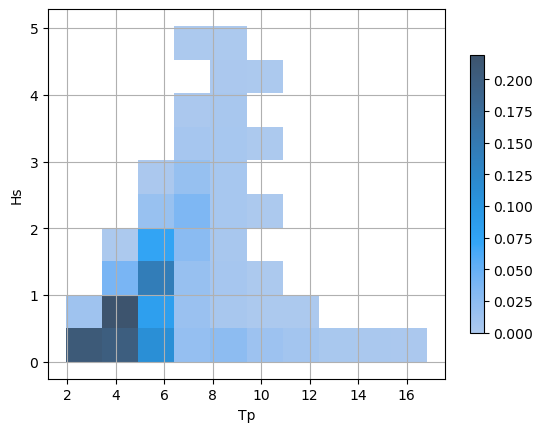

In [8]:
import seaborn as sns
import pandas as pd
import matplotlib.pylab as plt

dataIn = pd.read_csv('hsarrays.csv')

sns.histplot(data=dataIn, x = 'Tp', y = 'Hs', bins=10, cbar=True, cbar_kws=dict(shrink=.75), stat='density');
plt.grid()